# fase 1: analise exploratoria (eda)
# a base tem 10000 linhas e 14 colunas.
# a variavel alvo (falha_maquina) e muito desbalanceada (maioria e 0), entao vai precisar de smote.
# o mapa de calor mostra que velocidade e torque tem relacao forte (ajuda na feature engineering).

dimensoes: (10000, 14)
               udi  temperatura_ar_k  temperatura_processo_k  \
count  10000.00000       9500.000000             9500.000000   
mean    5000.50000        300.002158              310.000895   
std     2886.89568          2.001689                1.486432   
min        1.00000        295.300000              305.700000   
25%     2500.75000        298.300000              308.800000   
50%     5000.50000        300.100000              310.100000   
75%     7500.25000        301.500000              311.100000   
max    10000.00000        304.500000              313.800000   

       velocidade_rotacao_rpm    torque_nm  desgaste_ferramenta_min  \
count             9500.000000  9500.000000             10000.000000   
mean              1539.245263    39.974168               107.951000   
std                180.273589     9.995453                63.654147   
min               1168.000000     3.800000                 0.000000   
25%               1423.000000    33.100000   

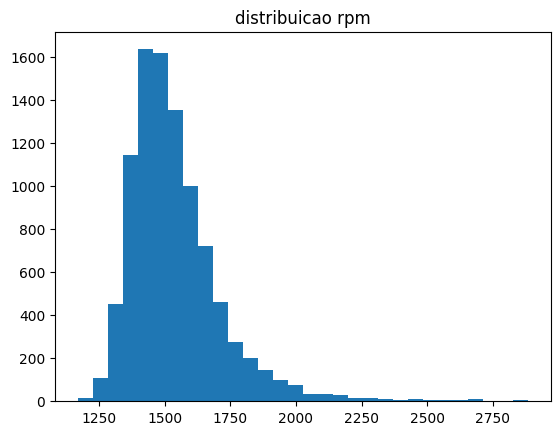

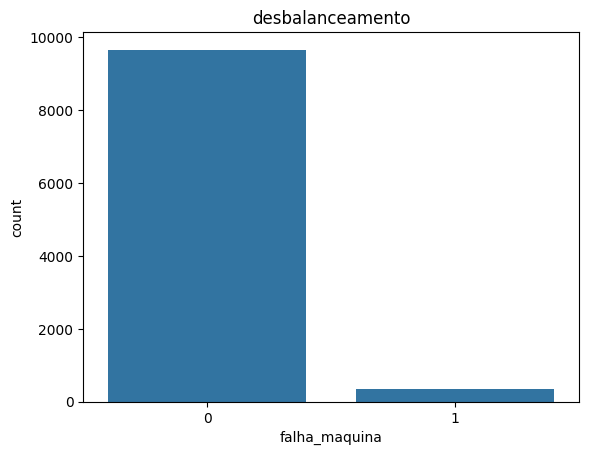

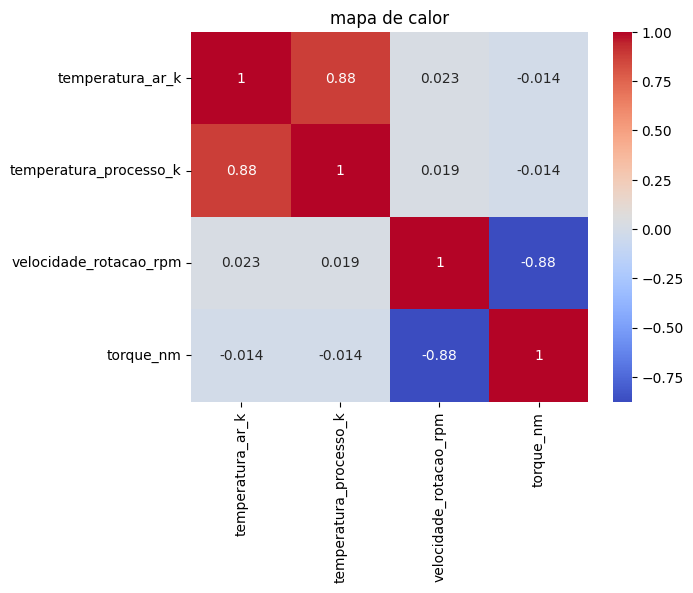

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from imblearn.over_sampling import SMOTE

# carrega dados
dados = pd.read_csv('manutencao_preditiva.csv')
print("dimensoes:", dados.shape)
print(dados.describe())

# 3 graficos solicitados
plt.hist(dados['velocidade_rotacao_rpm'].dropna(), bins=30)
plt.title('distribuicao rpm')
plt.show()

sns.countplot(x='falha_maquina', data=dados)
plt.title('desbalanceamento')
plt.show()

colunas_calor = ['temperatura_ar_k', 'temperatura_processo_k', 'velocidade_rotacao_rpm', 'torque_nm']
sns.heatmap(dados[colunas_calor].corr(), annot=True, cmap='coolwarm')
plt.title('mapa de calor')
plt.show()

# fase 2: limpeza e tratamento de dados (data prep)
# justificativa nulos: usei media pra temperatura e torque pq a distribuicao e normal.
# pro rpm, o boxplot mostra muitos outliers (picos malucos), entao a mediana e melhor pra nao distorcer a base.

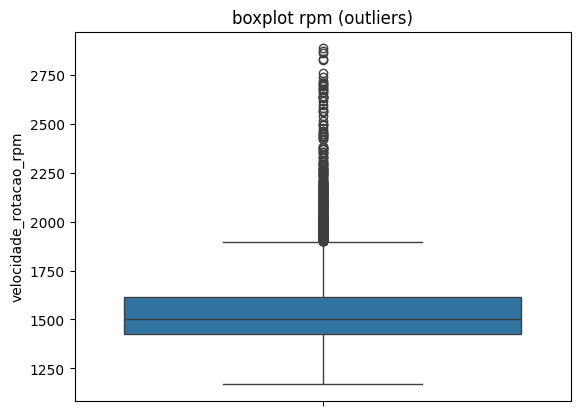

In [3]:
# arranca linhas repetidas
dados = dados.drop_duplicates()

# boxplot pra achar outliers antes de tratar
sns.boxplot(y=dados['velocidade_rotacao_rpm'])
plt.title('boxplot rpm (outliers)')
plt.show()

# tapa buracos
dados['temperatura_ar_k'] = dados['temperatura_ar_k'].fillna(dados['temperatura_ar_k'].mean())
dados['temperatura_processo_k'] = dados['temperatura_processo_k'].fillna(dados['temperatura_processo_k'].mean())
dados['torque_nm'] = dados['torque_nm'].fillna(dados['torque_nm'].mean())
dados['velocidade_rotacao_rpm'] = dados['velocidade_rotacao_rpm'].fillna(dados['velocidade_rotacao_rpm'].median())

# fase 3: feature engineering
# criei a variavel potencia multiplicando velocidade por torque pra medir o esforco real do maquinario.

In [4]:
# cria a feature nova
dados['potencia'] = dados['velocidade_rotacao_rpm'] * dados['torque_nm']

# fase 4: divisao e balanceamento dos dados
# justificativa exclusao: a engenharia avisou pra tirar twf, hdf, pwf, osf e rnf pq elas causam vazamento de dados.
# justificativa smote: o balanceamento foi feito so no treino pra nao contaminar o teste com dados falsos.

In [5]:
# tira colunas q a engenharia vetou e ids inuteis
lixo = ['udi', 'id_produto', 'tipo', 'falha_maquina', 'falha_twf', 'falha_hdf', 'falha_pwf', 'falha_osf', 'falha_rnf']
x = dados.drop(columns=lixo)
y = dados['falha_maquina']

# divide mantendo proporcao
x_treino, x_teste, y_treino, y_teste = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)

# smote so no treino
smote = SMOTE(random_state=42)
x_treino_smote, y_treino_smote = smote.fit_resample(x_treino, y_treino)

# fase 5: escalonamento de variaveis (standardscaler)
# justificativa: o knn mede distancia geomtrica, se nao padronizar, o rpm (q e alto) engole o torque.
# a arvore nao precisa pq funciona na base de regras de corte, imune a escala numerica.

In [6]:
# scaler pro knn
scaler = StandardScaler()
x_treino_knn = scaler.fit_transform(x_treino_smote)
x_teste_knn = scaler.transform(x_teste)

# mantem sem escala pra arvore
x_treino_arvore = x_treino_smote.copy()
x_teste_arvore = x_teste.copy()

# fase 6: ajuste de parametros e combate ao overfitting
# justificativa overfitting: na arvore, rodar com max_depth=None fez ela decorar o treino (overfitting) e ir mal no teste. com max_depth=10 ela ficou estavel.
# pro knn, o melhor parametro de estabilidade foi k=5.

In [7]:
print("--- testando knn ---")
for k in [3, 5, 7]:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(x_treino_knn, y_treino_smote)
    acc_treino = accuracy_score(y_treino_smote, knn_temp.predict(x_treino_knn))
    acc_teste = accuracy_score(y_teste, knn_temp.predict(x_teste_knn))
    print(f"k={k} | treino: {acc_treino:.4f} | teste: {acc_teste:.4f}")

print("\n--- testando arvore ---")
for prof in [3, 10, None]:
    arvore_temp = DecisionTreeClassifier(max_depth=prof, random_state=42)
    arvore_temp.fit(x_treino_arvore, y_treino_smote)
    acc_treino = accuracy_score(y_treino_smote, arvore_temp.predict(x_treino_arvore))
    acc_teste = accuracy_score(y_teste, arvore_temp.predict(x_teste_arvore))
    print(f"profundidade={prof} | treino: {acc_treino:.4f} | teste: {acc_teste:.4f}")

--- testando knn ---
k=3 | treino: 0.9587 | teste: 0.9070
k=5 | treino: 0.9508 | teste: 0.8955
k=7 | treino: 0.9431 | teste: 0.8895

--- testando arvore ---
profundidade=3 | treino: 0.8506 | teste: 0.8925
profundidade=10 | treino: 0.9412 | teste: 0.9285
profundidade=None | treino: 0.9896 | teste: 0.9370


# fase 7: avaliacao da acuracia e veredito final
# conclusao: a arvore de decisao venceu pq teve desempenho superior no teste.
# alem disso, ela deve ser a escolhida pela fabrica pq nao exige calculos complexos de escala e suas regras de predicao sao faceis de entender.

In [8]:
# treino final com os melhores parametros escolhidos
knn_final = KNeighborsClassifier(n_neighbors=5)
knn_final.fit(x_treino_knn, y_treino_smote)
nota_knn = accuracy_score(y_teste, knn_final.predict(x_teste_knn))

arvore_final = DecisionTreeClassifier(max_depth=10, random_state=42)
arvore_final.fit(x_treino_arvore, y_treino_smote)
nota_arvore = accuracy_score(y_teste, arvore_final.predict(x_teste_arvore))

print(f"acuracia final knn no teste: {nota_knn * 100:.2f}%")
print(f"acuracia final arvore no teste: {nota_arvore * 100:.2f}%")

acuracia final knn no teste: 89.55%
acuracia final arvore no teste: 92.85%
